---
# Parte I: Probabilidad Laplaciana, Condicional e Independencia
---


# Probabilidad Laplaciana


Para un experimento aleatorio se tiene que $\Omega$ es el espacio muestral (conjunto de posibles resultados).

Sea $A$ un evento, entonces definimos la probabilidad de $A$ como sigue:

$$ \mathbb{P}(A) = \frac{|A|}{|\Omega|}$$

**Ejemplo.** Sea el experimento de lanzar una moneda 3 veces, de manera independiente, es decir, el $i$-ésimo lanzamiento no afecta al $i+1$ lanzamiento. El espacio muestral es:

$$ \Omega = \{A,S\} \times \{A,S\} \times \{A,S\} = \{A,S\}^3, A = \{águilas\}, S = \{soles\}$$

$$ A \times B = \{(a,b) \mid a\in A, b \in B\}$$

y

$$\Omega =\{(s,s,s), (s,a,s), (s,s,a), (s,a,a), (a,a,a), (a,s,s), (a,s,a), (a,a,s)\}$$

y se tiene que $|\Omega| = 2^3 = 8$

Sean los eventos siguientes:

- $A$: todos los resultados son águilas
- $S$: todos los resultados son soles
- $E$: por lo menos un resultado es sol (1 o 2 o 3 son soles)


Vamos a calcular las probabilidades de $A,S$ y $E$

Primero para el evento $A$, vamos a descomponer al conjunto de la siguiente manera:

$$ A = A_1 \cap A_2 \cap A_3,$$
donde $A_i$: cae águila en el $i$-ésimo lanzamiento


### Vamos a crear el espacio muestral


In [2]:
# itertools: módulo estándar de Python para herramientas de iteración
# Nos permite generar combinaciones, permutaciones y productos cartesianos
import itertools as it
from itertools import product  # product(A, B, repeat=n) genera A×B×...×A (n veces)

In [3]:
# Generamos el espacio muestral Ω = {A, S}^3 con todas las combinaciones posibles
Omega = set(product({"A","S"}, repeat=3))  # repeat=3 indica 3 lanzamientos
Omega

{('A', 'A', 'A'),
 ('A', 'A', 'S'),
 ('A', 'S', 'A'),
 ('A', 'S', 'S'),
 ('S', 'A', 'A'),
 ('S', 'A', 'S'),
 ('S', 'S', 'A'),
 ('S', 'S', 'S')}

In [4]:
# Cardinalidad del espacio muestral (número de resultados posibles)
len(Omega)

8

### Vamos a crear el evento A


In [5]:
# Evento A_1: el primer lanzamiento cae en águila
A_1 = {om for om in Omega if om[0] == "A"}  # filtramos por la posición 0
A_1

{('A', 'A', 'A'), ('A', 'A', 'S'), ('A', 'S', 'A'), ('A', 'S', 'S')}

In [6]:
# Evento A_2: el segundo lanzamiento cae en águila
A_2 = {om for om in Omega if om[1] == "A"}  # filtramos por la posición 1
A_2

{('A', 'A', 'A'), ('A', 'A', 'S'), ('S', 'A', 'A'), ('S', 'A', 'S')}

In [7]:
# Evento A_3: el tercer lanzamiento cae en águila
A_3 = {om for om in Omega if om[2] == "A"}  # filtramos por la posición 2
A_3

{('A', 'A', 'A'), ('A', 'S', 'A'), ('S', 'A', 'A'), ('S', 'S', 'A')}

In [8]:
# Evento A: los tres lanzamientos son águila → A_1 ∩ A_2 ∩ A_3
A = A_1.intersection(A_2.intersection(A_3))  # intersección encadenada
A

{('A', 'A', 'A')}

In [9]:
card_A = len(A)  # número de elementos favorables al evento A

In [10]:
P_A = card_A / len(Omega)  # probabilidad clásica: casos favorables / casos totales
P_A

0.125

Ahora, si quiero expresar mi resultado en fracción utilizamos fractions


In [11]:
# fractions.Fraction: representa números racionales de forma exacta (sin redondeo)
# Útil cuando queremos probabilidades como 1/6 en lugar de 0.1666...
from fractions import Fraction

In [12]:
# Función de probabilidad laplaciana: P(E) = |E| / |Ω|
def p(E, Omega):
    p = Fraction(len(E), len(Omega))  # fracción exacta: casos favorables sobre totales
    return p

In [13]:
Pro_A = p(A, Omega)  # probabilidad de A expresada como fracción
Pro_A

Fraction(1, 8)

In [14]:
print(Pro_A)  # imprime la fracción de forma legible

1/8


### Vamos a crear el evento S


In [15]:
# Eventos individuales de sol para cada posición del lanzamiento
S_1 = {om for om in Omega if om[0] == "S"}  # sol en el primer lanzamiento
S_2 = {om for om in Omega if om[1] == "S"}  # sol en el segundo lanzamiento
S_3 = {om for om in Omega if om[2] == "S"}  # sol en el tercer lanzamiento

# Evento S: los tres lanzamientos son sol → S_1 ∩ S_2 ∩ S_3
S = S_1.intersection(S_2.intersection(S_3))
S

{('S', 'S', 'S')}

In [16]:
card_S = len(S)               # casos favorables al evento S
P_S = card_S / len(Omega)     # probabilidad en decimal
P_S

0.125

In [17]:
Pro_S = p(S, Omega)  # probabilidad de S como fracción exacta
Pro_S

Fraction(1, 8)

In [18]:
print(Pro_S)

1/8


### Vamos a crear el evento E


In [19]:
# Evento E: al menos un lanzamiento es sol → S_1 ∪ S_2 ∪ S_3
E = S_1.union(S_2.union(S_3))  # unión encadenada de los tres eventos
E

{('A', 'A', 'S'),
 ('A', 'S', 'A'),
 ('A', 'S', 'S'),
 ('S', 'A', 'A'),
 ('S', 'A', 'S'),
 ('S', 'S', 'A'),
 ('S', 'S', 'S')}

In [20]:
card_E = len(E)               # casos favorables al evento E
P_E = card_E / len(Omega)     # probabilidad en decimal
P_E

0.875

In [21]:
Pro_E = p(E, Omega)  # probabilidad de E como fracción exacta
Pro_E

Fraction(7, 8)

In [22]:
print(Pro_E)

7/8


# Probabilidad Condicional


Si añadimos condiciones a nuestro experimento aleatorio, la probabilidad cambia.

Definimos la probabilidad de que ocurra un evento $A$ **sabiendo** que ocurre un evento $B$, de la siguiente manera:

$$\mathbb{P}(A \mid B) \frac{\mathbb{A \cap B}}{\mathbb{P}(B)} = \frac{|A \cap B|}{|B|}$$

donde $$\mathbb{P}(B) > 0$$


In [23]:
# Función de probabilidad condicional: P(E|F) = |E ∩ F| / |F|
def p_cond(E, F):
    return len(E & F) / len(F)  # & calcula la intersección de los conjuntos

Queremos calcular la probabilidad condicional de los eventos siguientes:

- $B$: el primer lanzamiento es águila
- $C$: dos de los resultados son águila (exactamente)

Quiero $\mathbb{P}(B\mid C)$


In [24]:
# Evento B: el primer lanzamiento es águila
B = {om for om in Omega if om[0] == "A"}

In [25]:
# Evento C: exactamente dos de los tres lanzamientos son águila
C = {om for om in Omega if om.count("A") == 2}  # count() cuenta ocurrencias en la tupla
C

{('A', 'A', 'S'), ('A', 'S', 'A'), ('S', 'A', 'A')}

In [26]:
p_BC = p_cond(B, C)     # P(B|C): probabilidad de B dado que ocurrió C
print(p_BC)
print(Fraction(p_BC))   # convertimos a fracción para mayor precisión

0.6666666666666666
6004799503160661/9007199254740992


In [27]:
p_CB = p_cond(C, B)     # P(C|B): probabilidad de C dado que ocurrió B
print(p_CB)
print(Fraction(p_CB))

0.5
1/2


## Independencia de eventos


Decimos que dos eventos $A$ y $B$ son independientes si

$$\mathbb{P}(A \cap B) = \mathbb{P}(A)\mathbb{P}(B)$$


In [28]:
# Función auxiliar: probabilidad usando el Ω del ámbito global
def prob(E):
    return len(E) / len(Omega)

In [29]:
# Verificar independencia: P(E ∩ F) = P(E)·P(F)
def indep(E, F):
    return prob(E & F) == prob(E) * prob(F)  # retorna True si son independientes

In [30]:
indep(B, C)  # verificamos si B y C son independientes

False

**Ejemplo.** Sea el experimento aleatorio de lanzar un dado honesto 2 veces. Sabemos que:

$$\Omega = \{(i,j)\mid i,j \in \{1,2,3,4,5,6\}\} $$

y además $|\Omega| = 6^2 = 36$


In [31]:
# Espacio muestral para dos dados: todos los pares (i, j) con i, j ∈ {1,...,6}
Omega_dado = set(product([1,2,3,4,5,6], repeat=2))

# Cardinalidad del espacio muestral: 6 × 6 = 36
card_dado = len(Omega_dado)
card_dado

36

Definimos el evento

- $S_n$: la suma de los dados es $n$, donde $n\in\{2,\dots,12\}$

$$ S_n = \{(i,j) \in \Omega \mid i+j = n \}$$


In [32]:
# Función que devuelve el evento S_n: todos los pares cuya suma es n
def S(n):
    Sn = {(i,j) for i in range(1,7) for j in range(1,7) if i+j == n}  # filtra por suma
    return Sn

In [33]:
S_siete = S(7)  # todos los pares de dados que suman 7
S_siete

{(1, 6), (2, 5), (3, 4), (4, 3), (5, 2), (6, 1)}

In [34]:
len(S_siete) / card_dado  # P(S_7): casos favorables entre total de resultados posibles

0.16666666666666666

---
# Parte II: Variable Aleatoria y su Ley
---


# La variable aleatoria asociada al evento $S_n$


## Introducción a los diccionarios en python


Un diccionario en Python es un objeto que se crea a partir de algo que se llama "llave" y nos arroja "valores".

$$ \{\text{key (llave)}: \text{valores}\}$$


In [35]:
# Creamos un diccionario con llaves (strings) y sus valores asociados
dic1 = {
    "Claudia": ["Masha","Snow"],         # lista de mascotas
    "Calificaciones": [10,9, 8, 9.5],   # lista de calificaciones
    "Documento": ["G2436778"]            # número de documento
}

dic1

{'Claudia': ['Masha', 'Snow'],
 'Calificaciones': [10, 9, 8, 9.5],
 'Documento': ['G2436778']}

In [36]:
# Accedemos al valor de la llave "Calificaciones"
calif = dic1["Calificaciones"]
calif

[10, 9, 8, 9.5]

In [37]:
dic1["Calificaciones"][3]  # accedemos al cuarto elemento (índice 3) de la lista

9.5

Otra forma de crear diccionarios es usando `dict()` de la forma `(llave,valor)`


In [38]:
# Forma alternativa: dict() recibe una lista de pares (llave, valor)
dict([
    ("Claudia", ["Masha","Snow"]),
    ("Calificaciones", [10,9, 8, 9.5]),
    ("Documento", ["G2436778"])
])

{'Claudia': ['Masha', 'Snow'],
 'Calificaciones': [10, 9, 8, 9.5],
 'Documento': ['G2436778']}

In [39]:
# itertools: módulo estándar de Python para herramientas de iteración
import itertools as it
from itertools import product  # product genera el producto cartesiano de iterables

In [40]:
# Espacio muestral: todos los pares (i, j) al lanzar dos dados de 6 caras
Omega = set(product([1,2,3,4,5,6], repeat=2))

In [41]:
# Diccionario que asocia cada par (i, j) con su suma i+j
Sn = {(i,j):i+j for i,j in Omega}
# La llave es el par de resultados y el valor es la suma
#Sn

In [42]:
# collections.defaultdict: diccionario que asigna un valor por defecto a llaves nuevas
# defaultdict(set) crea un conjunto vacío set() automáticamente para llaves no vistas
# Evita el error KeyError al acceder a una llave que aún no existe
from collections import defaultdict

In [43]:
dSn = defaultdict(set)  # agrupará los pares (i,j) por su suma

In [44]:
# Recorremos Sn para agrupar los pares según su suma
for i,j in Sn.items():    # i = par (a,b), j = su suma a+b
    dSn[j].add(i)          # añadimos el par al conjunto de su suma correspondiente

In [45]:
list(dSn.items())  # mostramos los grupos: {suma: {pares que producen esa suma}}

[(7, {(1, 6), (2, 5), (3, 4), (4, 3), (5, 2), (6, 1)}),
 (4, {(1, 3), (2, 2), (3, 1)}),
 (9, {(3, 6), (4, 5), (5, 4), (6, 3)}),
 (10, {(4, 6), (5, 5), (6, 4)}),
 (6, {(1, 5), (2, 4), (3, 3), (4, 2), (5, 1)}),
 (8, {(2, 6), (3, 5), (4, 4), (5, 3), (6, 2)}),
 (11, {(5, 6), (6, 5)}),
 (3, {(1, 2), (2, 1)}),
 (5, {(1, 4), (2, 3), (3, 2), (4, 1)}),
 (2, {(1, 1)}),
 (12, {(6, 6)})]

## La ley de una variable aleatoria

Recordemos que una variable aleatoria real $X$ es una función $X: \Omega \to \mathbb{R}$.

Sabemos que la **ley de una variable aleatoria discreta** $X$ (función de masa de probabilidad) se define como:

$$f_{X}(x) = \begin{cases} \mathbb{P}(X=x), & \text{si } x \in R_{X} \\ 0, & \text{en otro caso} \end{cases}$$

donde $R_{X}$ es el rango de $X$ (conjunto de valores que puede tomar).

Para nuestra variable $S_n$ (suma de dos dados):
$$S_n : \Omega \to \{2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12\}$$


In [46]:
# fractions.Fraction: aritmética exacta con fracciones (sin errores de punto flotante)
from fractions import Fraction

In [47]:
# Función de probabilidad: recibe un evento A y devuelve P(A) como fracción
def P(A):
    P = Fraction(len(A),len(Omega))  # |A| / |Ω| como fracción exacta
    return P

In [48]:
# Construimos la ley de S_n: a cada valor k le asignamos P(S_n = k)
LeySn = {i : P(A) for i,A in dSn.items()}
LeySn

{7: Fraction(1, 6),
 4: Fraction(1, 12),
 9: Fraction(1, 9),
 10: Fraction(1, 12),
 6: Fraction(5, 36),
 8: Fraction(5, 36),
 11: Fraction(1, 18),
 3: Fraction(1, 18),
 5: Fraction(1, 9),
 2: Fraction(1, 36),
 12: Fraction(1, 36)}

In [49]:
# pandas: biblioteca para análisis y manipulación de datos en Python
# Ofrece Series (arreglo con índice) y DataFrame (tabla 2D con etiquetas)
import pandas as pd

In [50]:
# Convertimos el diccionario de la ley en una Serie de pandas
Ley_Sn = pd.Series(LeySn)  # el índice queda como los valores posibles de S_n
Ley_Sn

7      1/6
4     1/12
9      1/9
10    1/12
6     5/36
8     5/36
11    1/18
3     1/18
5      1/9
2     1/36
12    1/36
dtype: object

In [51]:
# Ordenamos la serie por índice (de menor a mayor)
Ley_Sn = Ley_Sn.sort_index()  # sort_index() devuelve una nueva serie ordenada
Ley_Sn

2     1/36
3     1/18
4     1/12
5      1/9
6     5/36
7      1/6
8     5/36
9      1/9
10    1/12
11    1/18
12    1/36
dtype: object

In [52]:
# Función que devuelve P(S_n = i) para i en el rango válido
def LeyS(i):
    if i in range(2, 13):    # valores posibles de S_n: de 2 a 12
        x = Ley_Sn[i]
    else:
        x = 0                # fuera del rango, la probabilidad es 0
    return print(x)

In [53]:
rango_S = [k for k in range(2,13)]              # valores posibles de S_n: de 2 a 12
p_k = [float(Ley_Sn[k]) for k in rango_S]      # probabilidades en formato decimal
p_k

[0.027777777777777776,
 0.05555555555555555,
 0.08333333333333333,
 0.1111111111111111,
 0.1388888888888889,
 0.16666666666666666,
 0.1388888888888889,
 0.1111111111111111,
 0.08333333333333333,
 0.05555555555555555,
 0.027777777777777776]

In [54]:
sum(p_k)  # verificamos que las probabilidades sumen 1 (axioma de normalización)

1.0

In [55]:
# DataFrame con los valores de S_n y sus probabilidades
lS = pd.DataFrame(
    list(zip(rango_S, p_k)),                              # pares (valor, probabilidad)
    index = [f'S_{i}' for i in range(len(rango_S))],     # etiquetas S_0, S_1, ...
    columns=['S_n', 'P(S_n)']                            # nombres de columnas
)
lS

,S_n,P(S_n)
S_0,2,0.027778
S_1,3,0.055556
S_2,4,0.083333
S_3,5,0.111111
S_4,6,0.138889
S_5,7,0.166667
S_6,8,0.138889
S_7,9,0.111111
S_8,10,0.083333
S_9,11,0.055556


In [56]:
# matplotlib.pyplot: módulo de graficación al estilo MATLAB
# plt es el alias estándar; con él se crean y personalizan figuras y gráficas
import matplotlib.pyplot as plt

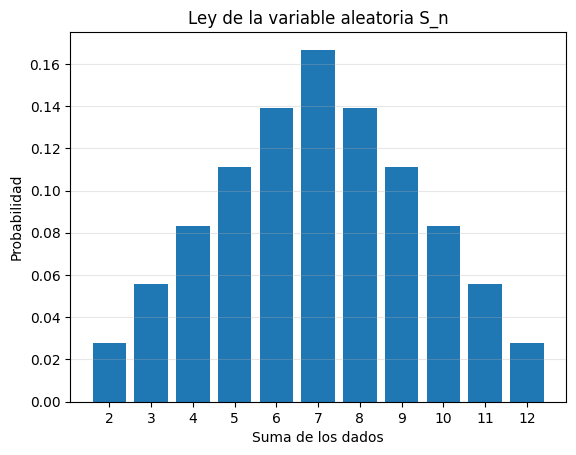

In [57]:
plt.bar(Ley_Sn.index, Ley_Sn.values)          # gráfica de barras: valor vs probabilidad
plt.grid(alpha=0.3, axis='y')                  # rejilla horizontal con transparencia
plt.xlabel('Suma de los dados')                # etiqueta eje x
plt.ylabel('Probabilidad')                     # etiqueta eje y
plt.title('Ley de la variable aleatoria S_n')  # título de la gráfica
plt.xticks(Ley_Sn.index)                       # marca cada valor posible en el eje x
plt.show()

---
# Parte III: Probabilidad Frecuentista
---


# Probabilidad Frecuentista


**Jacob Bernoulli** en 1713 formuló y demostró una versión temprana de la ley de los grandes números

Sea un espacio muestral (un vonjunto finito) y podemos definir la probabilidad asociada a un evento $A$ donde tengo un experimento aleatorio que se realiza $n$ veces:

$$f_{n} (A) = \frac{n(A)}{n}$$

donde $n(A)$ es el número de veces que ocurre $A$.


Sea el experimento aleatoriode lanzar una moneda (no justa).


In [58]:
# random: módulo estándar de Python para generación de números pseudoaleatorios
# Incluye funciones para distribución uniforme, muestras, barajos, etc.
import random

In [59]:
def volado(p):  # p: probabilidad de obtener sol
    # Si el número aleatorio cae dentro de [0, p) → sol; si no → águila
    return "sol" if random.random() < p else "aguila"
    # random.random() devuelve un float uniforme en [0.0, 1.0)

In [60]:
volado(0.4)  # prueba: un solo lanzamiento con p(sol) = 0.4

'sol'

In [61]:
# Lista de 10 lanzamientos usando comprensión de lista
vol = [volado(0.4) for i in range(10)]  # range(10): contador de 0 a 9
vol

['sol',
 'sol',
 'sol',
 'sol',
 'aguila',
 'aguila',
 'aguila',
 'aguila',
 'aguila',
 'aguila']

In [62]:
vol.count('sol')  # contamos cuántas veces apareció sol en los 10 lanzamientos

4

In [63]:
vol.count('aguila')  # contamos cuántas veces apareció águila

6

Otra manera sería por medio de un bucle:


In [64]:
resultados = []          # lista vacía para almacenar los resultados
for i in range(10):
    resultado = volado(0.4)         # un lanzamiento con p(sol) = 0.4
    resultados.append(resultado)    # agregamos el resultado a la lista
resultados

['sol',
 'aguila',
 'sol',
 'sol',
 'aguila',
 'aguila',
 'sol',
 'aguila',
 'aguila',
 'aguila']

Ahora, vamos a simular nuestra probabilidad frecuentista:

Un experimento con 1,000 volados (individual) y puedo repetir 500 experimentos (500 de nosotros)


In [65]:
# Simulación: 500 experimentos de 1,000 volados cada uno
p = []  # guarda la frecuencia relativa de sol por experimento

for i in range(500):              # 500 experimentos independientes
    N = 1000                       # lanzamientos por experimento
    resultados = []                # resultados del experimento i

    for j in range(N):
        resultado = volado(0.7)            # lanzamiento con p(sol) = 0.7
        resultados.append(resultado)

    n_soles = resultados.count("sol")     # número de soles en este experimento
    p_soles = n_soles / N                  # frecuencia relativa de sol

    # Añadimos la frecuencia del experimento a la lista
    p.append(p_soles)

    # Promedio acumulado (converge a 0.7 por la ley de los grandes números)
    p_soles_prom = sum(p)/len(p)

p_soles_prom

0.699018

In [66]:
# Función completa by Misael
def probafrec(p, experimentos, volados):
    p_total = []                          # frecuencia relativa de cada experimento

    for i in range(experimentos):         # iteramos sobre los experimentos
        resultados = []

        for j in range(volados):           # simulamos cada lanzamiento del experimento i
            resultado = "sol" if random.random() < p else "aguila"  # lanzamiento individual
            resultados.append(resultado)

        n_soles = resultados.count("sol")  # número de soles en este experimento
        p_soles = n_soles / N              # frecuencia relativa de sol

        p_total.append(p_soles)            # guardamos la frecuencia del experimento i

        # Promedio acumulado de frecuencias (ley de los grandes números)
        p_soles_prom = sum(p_total)/len(p_total)

    return p_soles_prom


In [67]:
probafrec(0.9, 500, 1000)  # estimamos P(sol) con p=0.9, 500 experimentos, 1000 volados

0.90051

---
# Parte IV: Probabilidad Geométrica — El Problema del Encuentro
---


## Definición: Probabilidad Geométrica

Cuando el espacio muestral $\Omega$ es un conjunto continuo (un intervalo, un área, un volumen), la probabilidad laplaciana clásica no aplica directamente.

En ese caso se utiliza la **probabilidad geométrica**, donde la medida de un conjunto es su longitud, área o volumen:

$$\mathbb{P}(A) = \frac{\text{medida}(A)}{\text{medida}(\Omega)}$$

**Para el problema del encuentro:**

- $\Omega = [0,60] \times [0,60]$ es un cuadrado de área $60^2 = 3600$
- $A = \{(x,y) \mid |x - y| \leq 10\}$ es la franja diagonal donde se encuentran
- La probabilidad exacta es:

$$\mathbb{P}(A) = 1 - \left(\frac{50}{60}\right)^2 = 1 - \frac{25}{36} = \frac{11}{36} \approx 0.3056$$

La simulación de Monte Carlo estima esta probabilidad muestreando puntos aleatorios en $\Omega$.


# El problema del encuentro


Romeo y Julieta planean encontrarse en un lugar específico entre $[0,60]$ minutos (1 hora).

- Si romeo llega primero, entonces piensa esperar 10 minutos
- Si julieta llega primero, entonces piensa esperar 10 minutos

Se elige un número al azar entre $[0,60]$, y supongamos que el par de números se elige sobre el cuadrado de modo que la probabilidad de un evento sea el área favorable entre el área total.

Sea
$A$: Romeo y Julieta se encuentran a una distancia de 10 minutos

Me gustaría encontrar la probabilidad de $A$.


In [68]:
# numpy: biblioteca fundamental de computación científica en Python
# Permite crear arreglos vectorizados y operar sobre ellos sin bucles explícitos
import numpy as np

# matplotlib.pyplot: módulo de graficación; plt es el alias estándar
import matplotlib.pyplot as plt

La probabilidad del evento A es: 0.329.


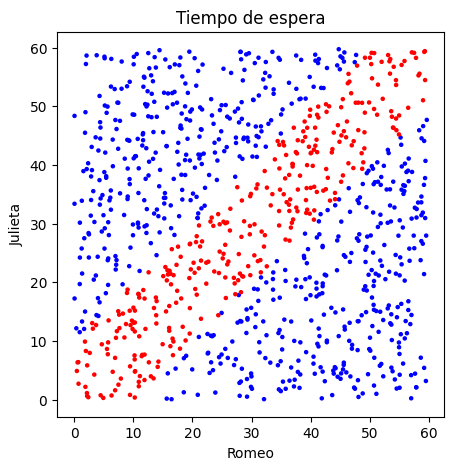

In [69]:
# Generamos 1000 simulaciones del experimento
muestra = 1000

# Tiempos de llegada uniformes en [0, 60] minutos
x = np.random.uniform(0, 60, muestra)  # tiempo de llegada de Romeo
y = np.random.uniform(0, 60, muestra)  # tiempo de llegada de Julieta

# Condición de encuentro: la diferencia de llegada es menor o igual a 10 minutos
encuentro = np.where(abs(x-y) <= 10, 'r', 'b')  # 'r' = se encuentran, 'b' = no se encuentran

# Contamos cuántas simulaciones resultaron en encuentro
k = 0
for elemento in encuentro:
    if elemento == 'r':
        k += 1  # incrementamos el contador de encuentros
print("La probabilidad del evento A es: {}.".format(k/muestra))

# Gráfica de dispersión: rojo = se encuentran, azul = no se encuentran
plt.figure(figsize=(5,5))               # tamaño de la figura
plt.scatter(x, y, c=encuentro, s=5)    # s=5: tamaño de cada punto
plt.title("Tiempo de espera")
plt.ylabel("Julieta")
plt.xlabel("Romeo")
plt.show()